# STEP 1: IMPORT REQUIRED LIBRARIES

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Data Splitting & Model Tuning

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)


# Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier


# Model Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# Explainable AI (XAI)

import shap


# Notebook Settings

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("All libraries imported successfully.")

All libraries imported successfully.


# INSTALL REQUIRED PACKAGES

In [2]:
# Install XGBoost and SHAP
!pip install xgboost shap -q

print("Packages installed successfully.")

Packages installed successfully.


# STEP 2: LOAD DATASET AND INITIAL EXPLORATION

Dataset Shape:
(4756, 31)

First 5 Rows:


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 

,0
employment_sector,2364
health_insurance,1925
income_poverty,712
doctor_recc_h1n1,319
rent_or_own,315
employment_status,235
marital_status,226
education,224
chronic_med_condition,161
child_under_6_months,134



Missing Values Percentage:


,0
employment_sector,49.705635
health_insurance,40.475189
income_poverty,14.970563
doctor_recc_h1n1,6.707317
rent_or_own,6.623213
employment_status,4.941127
marital_status,4.751892
education,4.709840
chronic_med_condition,3.385198
child_under_6_months,2.817494



Target Distribution:


,count
h1n1_vaccine,
0,2882
1,1874



Target Distribution Percentage:


,proportion
h1n1_vaccine,
0,60.59714
1,39.40286


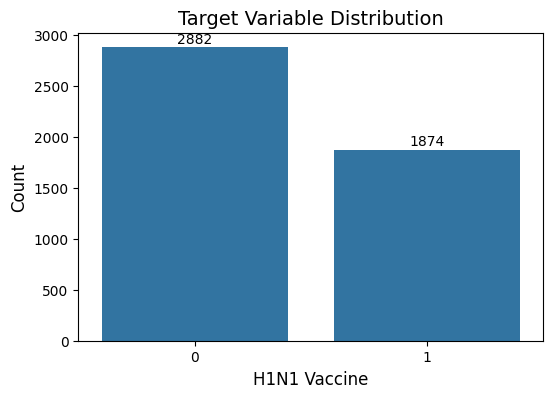

In [4]:
# Load the training dataset
df = pd.read_csv("dataset_B_training.csv")


# Dataset Shape

print("Dataset Shape:")
print(df.shape)


# Display First 5 Rows

print("\nFirst 5 Rows:")
display(df.head())


# Dataset Information

print("\nDataset Information:")
df.info()


# Missing Values Analysis

print("\nMissing Values Count:")

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

display(missing_values)


# Missing Values Percentage

print("\nMissing Values Percentage:")

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_percent = missing_percent[missing_percent > 0]
missing_percent = missing_percent.sort_values(ascending=False)

display(missing_percent)


# Target Variable Distribution

print("\nTarget Distribution:")

display(
    df['h1n1_vaccine'].value_counts()
)


# Target Variable Percentage

print("\nTarget Distribution Percentage:")

display(
    df['h1n1_vaccine']
    .value_counts(normalize=True) * 100
)


# Target Distribution Plot

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='h1n1_vaccine'
)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=1
    )

plt.title("Target Variable Distribution", fontsize=14)
plt.xlabel("H1N1 Vaccine", fontsize=12)
plt.ylabel("Count", fontsize=12)


plt.show()

# STEP 3: FEATURE UNDERSTANDING AND MISSING VALUE ANALYSIS

Number of Rows: 4756
Number of Columns: 31

Duplicate Rows:
0

Data Types Summary:


,count
float64,19
object,10
int64,2



Numerical Features: 21
['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children', 'h1n1_vaccine']

Categorical Features: 10
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']

Missing Values Summary:


,Missing Count,Missing Percentage (%)
employment_sector,2364,49.71
health_insurance,1925,40.48
income_poverty,712,14.97
doctor_recc_h1n1,319,6.71
rent_or_own,315,6.62
employment_status,235,4.94
marital_status,226,4.75
education,224,4.71
chronic_med_condition,161,3.39
child_under_6_months,134,2.82


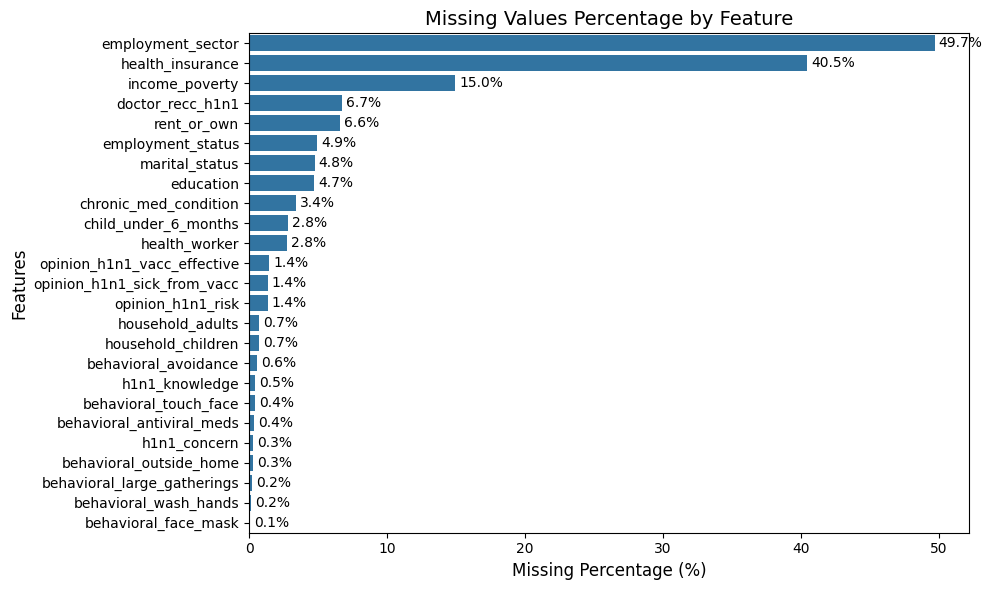

In [6]:
# Dataset Summary

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


# Check Duplicate Records

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# Data Types Summary

print("\nData Types Summary:")

display(
    df.dtypes.value_counts()
)


# Separate Numerical and Categorical Features

numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Features:", len(numerical_cols))
print(numerical_cols)

print("\nCategorical Features:", len(categorical_cols))
print(categorical_cols)


# Missing Values Summary Table

missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )
})

missing_table = missing_table[
    missing_table['Missing Count'] > 0
]

missing_table = missing_table.sort_values(
    by='Missing Percentage (%)',
    ascending=False
)

print("\nMissing Values Summary:")

display(missing_table)


# Missing Values Visualization

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=missing_table['Missing Percentage (%)'],
    y=missing_table.index
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.title("Missing Values Percentage by Feature", fontsize=14)
plt.xlabel("Missing Percentage (%)", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

# STEP 4: DISTRIBUTION ANALYSIS AND CORRELATION ANALYSIS


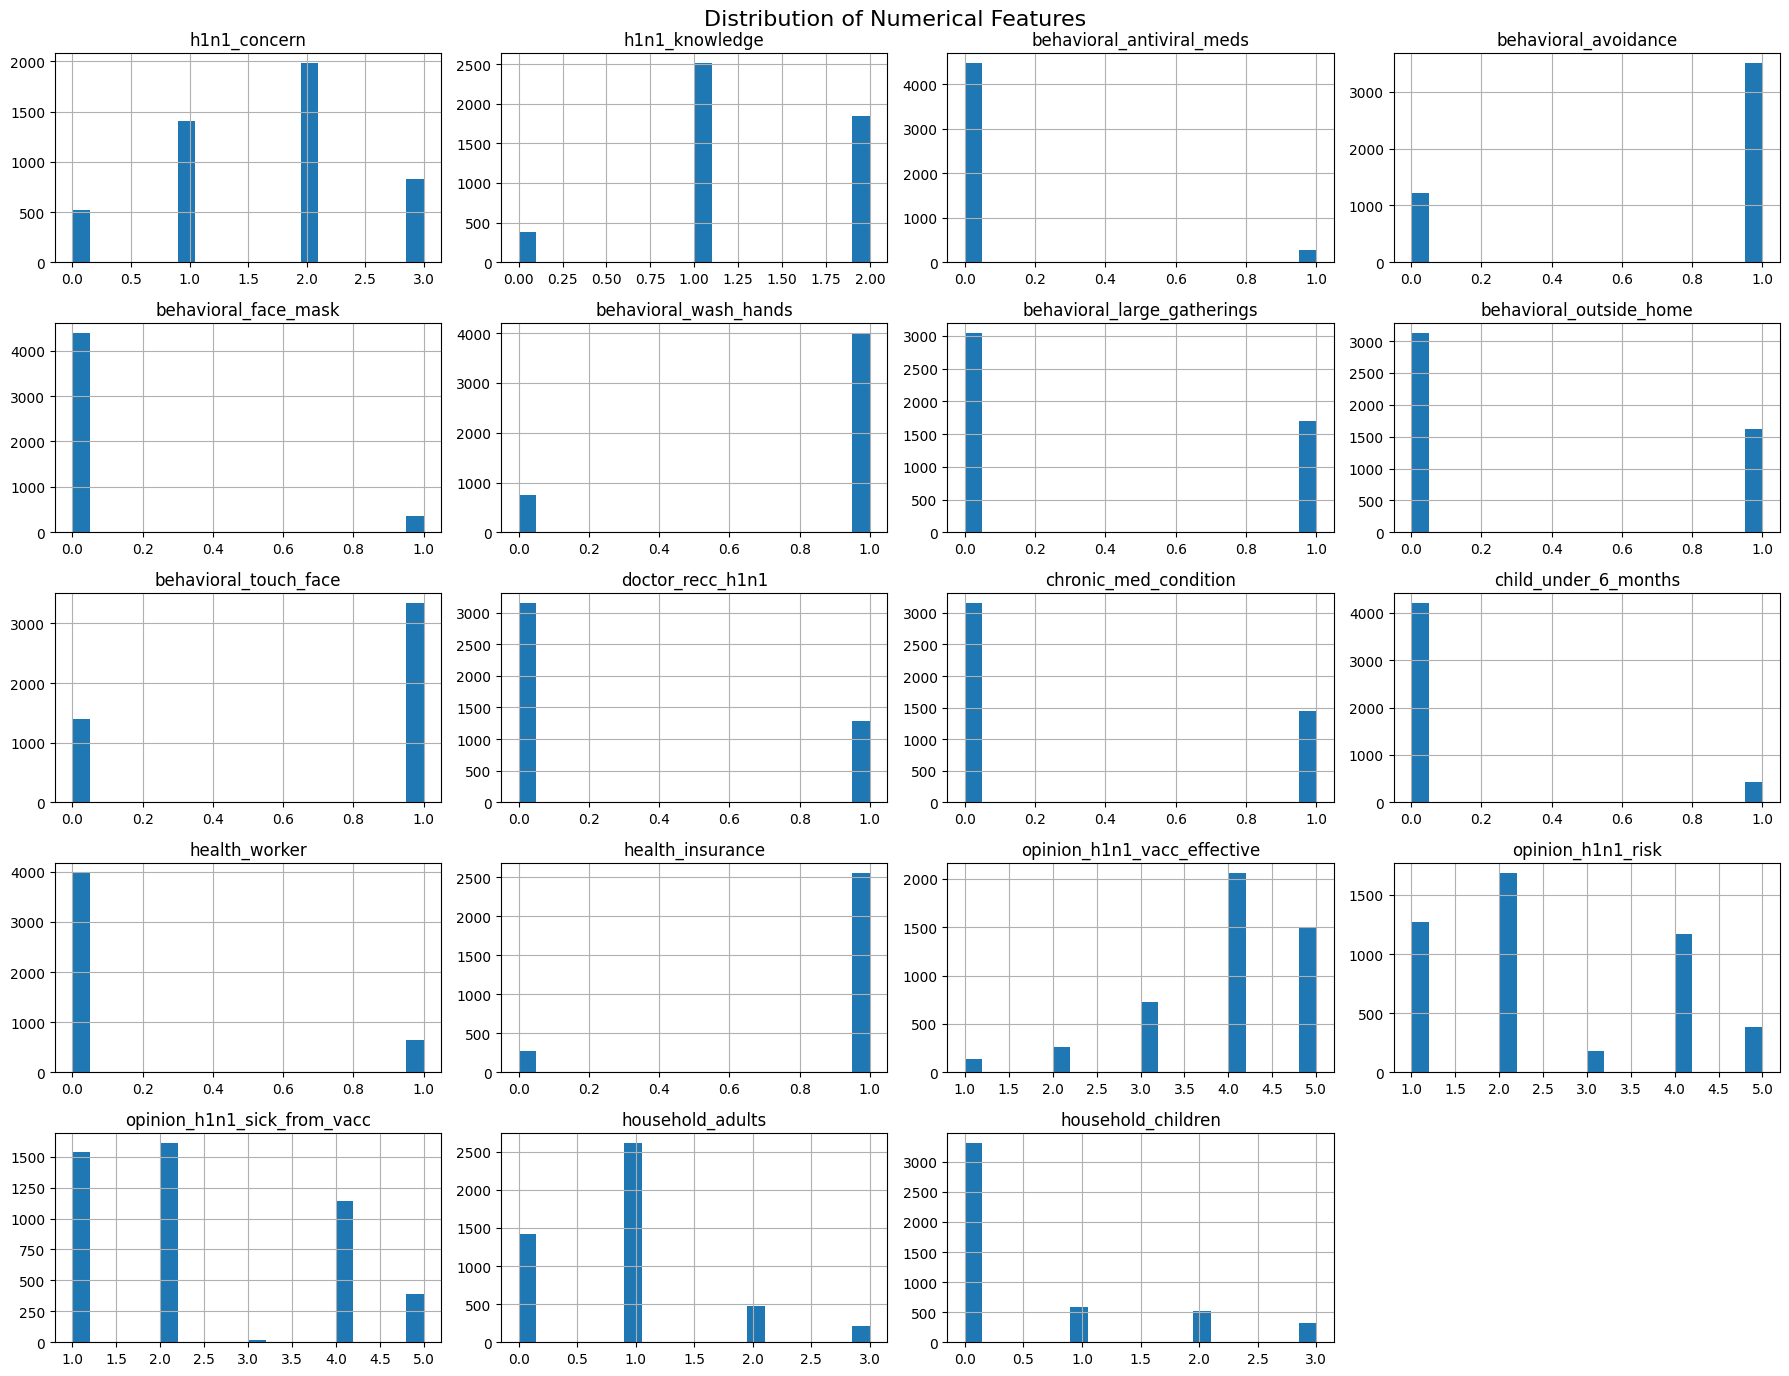

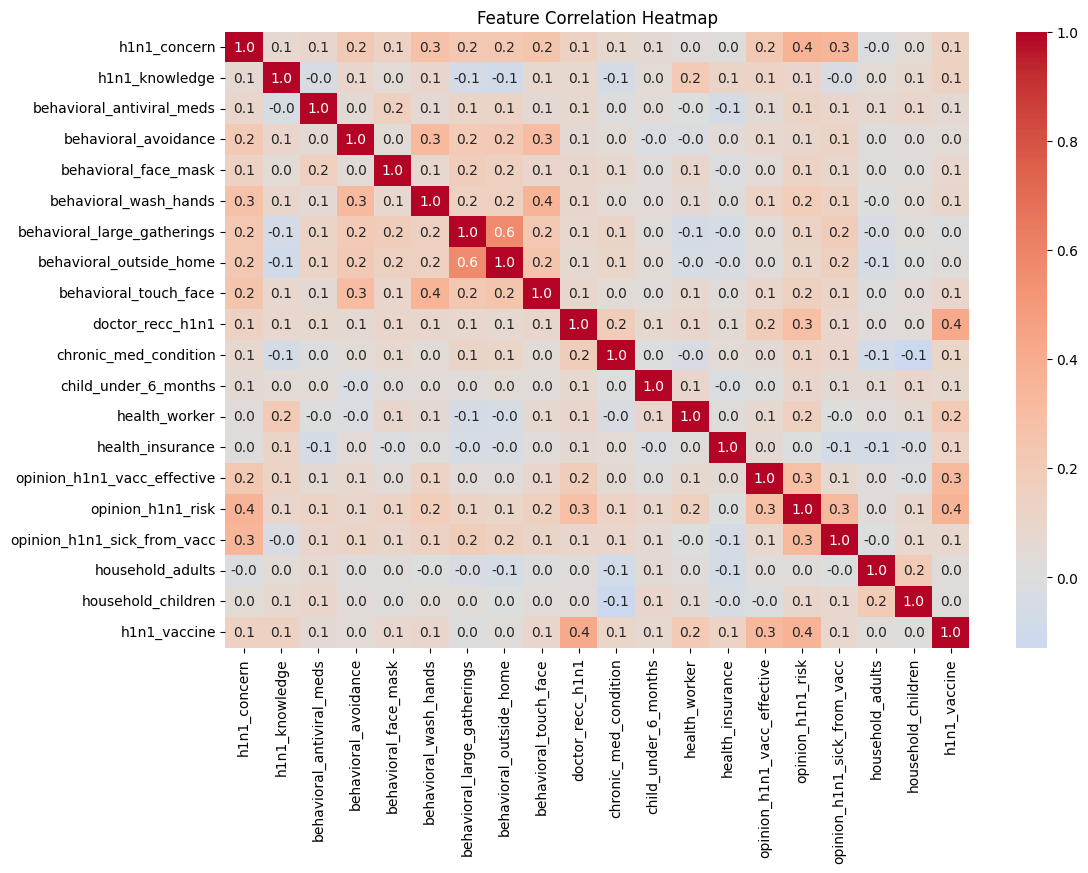

In [7]:

# STEP 4: DISTRIBUTION ANALYSIS AND CORRELATION ANALYSIS


# Select Numerical Features for EDA


eda_num_cols = [
    col for col in numerical_cols
    if col not in ['respondent_id', 'h1n1_vaccine']
]


# Feature Distribution Analysis


df[eda_num_cols].hist(
    figsize=(18, 14),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


# Correlation Analysis


corr = df.drop(columns=['respondent_id']).select_dtypes(
    include=['int64','float64']
).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".1f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# STEP 5: PREPARE FEATURES AND TARGET VARIABLE

In [8]:
# Remove Identifier Column


# respondent_id is a unique identifier and
# should not be used for model training

df_model = df.drop(
    'respondent_id',
    axis=1
)


# Define Target Variable


target = 'h1n1_vaccine'


# Separate Features and Target


X = df_model.drop(
    target,
    axis=1
)

y = df_model[target]


# Verify Dataset Dimensions


print("Feature Matrix Shape:")
print(X.shape)

print("\nTarget Vector Shape:")
print(y.shape)


# Check Target Distribution


print("\nTarget Distribution:")

print(
    y.value_counts()
)

Feature Matrix Shape:
(4756, 29)

Target Vector Shape:
(4756,)

Target Distribution:
h1n1_vaccine
0    2882
1    1874
Name: count, dtype: int64


# STEP 6: TRAIN-TEST SPLIT

In [10]:
# Split Dataset into Training and Testing Sets


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Display Dataset Shapes


print("Training Features Shape:")
print(X_train.shape)
print("\nTesting Features Shape:")
print(X_test.shape)


# Check Target Distribution


print("\nTraining Target Distribution:")

print(
    y_train.value_counts(normalize=True)
)

print("\nTesting Target Distribution:")

print(
    y_test.value_counts(normalize=True)
)

Training Features Shape:
(3804, 29)

Testing Features Shape:
(952, 29)

Training Target Distribution:
h1n1_vaccine
0    0.605941
1    0.394059
Name: proportion, dtype: float64

Testing Target Distribution:
h1n1_vaccine
0    0.606092
1    0.393908
Name: proportion, dtype: float64


# STEP 7: DEFINE FEATURE GROUPS

In [11]:

# Binary Features

# These features contain two possible values (0 or 1)

binary_features = [
    'behavioral_antiviral_meds',
    'behavioral_avoidance',
    'behavioral_face_mask',
    'behavioral_wash_hands',
    'behavioral_large_gatherings',
    'behavioral_outside_home',
    'behavioral_touch_face',
    'doctor_recc_h1n1',
    'chronic_med_condition',
    'child_under_6_months',
    'health_worker',
    'health_insurance'
]

# Ordinal Features

# These features represent ordered categories
# where the numerical values have meaning

ordinal_features = [
    'h1n1_concern',
    'h1n1_knowledge',
    'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc',
    'household_adults',
    'household_children'
]


# Nominal Categorical Features

# These features have categories with no
# natural ordering

categorical_features = [
    'age_group',
    'education',
    'race',
    'sex',
    'income_poverty',
    'marital_status',
    'rent_or_own',
    'employment_status',
    'census_msa',
    'employment_sector'
]


# Verify Feature Counts


print("Binary Features:", len(binary_features))
print("Ordinal Features:", len(ordinal_features))
print("Categorical Features:", len(categorical_features))

print(
    "\nTotal Features:",
    len(binary_features)
    + len(ordinal_features)
    + len(categorical_features)
)

Binary Features: 12
Ordinal Features: 7
Categorical Features: 10

Total Features: 29


# STEP 8: DATA PREPROCESSING PIPELINE

In [12]:

# STEP 8: DATA PREPROCESSING PIPELINE


# Binary Features Pipeline

# Missing values are replaced using
# the most frequent value (mode)

binary_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    )
])


# Ordinal Features Pipeline

# Missing values are replaced using
# K-Nearest Neighbour (kNN) Imputation
#
# Features are then standardised
# using StandardScaler

ordinal_transformer = Pipeline([
    (
        'imputer',
        KNNImputer(n_neighbors=5)
    ),
    (
        'scaler',
        StandardScaler()
    )
])


# Categorical Features Pipeline

# Missing values are replaced using
# the most frequent value (mode)
#
# One-Hot Encoding converts
# categorical values into numerical features

categorical_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'onehot',
        OneHotEncoder(handle_unknown='ignore')
    )
])


# Combine All Preprocessing Steps


preprocessor = ColumnTransformer([
    (
        'binary',
        binary_transformer,
        binary_features
    ),
    (
        'ordinal',
        ordinal_transformer,
        ordinal_features
    ),
    (
        'categorical',
        categorical_transformer,
        categorical_features
    )
])

print("Preprocessing Pipeline Created Successfully.")

Preprocessing Pipeline Created Successfully.


#STEP 9: APPLY DATA PREPROCESSING

In [13]:

# Fit Preprocessor on Training Data

# The preprocessing pipeline learns:
# - Missing value replacement rules
# - Scaling parameters
# - One-Hot Encoding categories

X_train_processed = preprocessor.fit_transform(
    X_train
)


# Apply Preprocessor to Testing Data

# Use the same preprocessing rules
# learned from the training data

X_test_processed = preprocessor.transform(
    X_test
)


# Compare Dataset Dimensions


print("Original Training Shape:")
print(X_train.shape)

print("\nProcessed Training Shape:")
print(X_train_processed.shape)

print("\nOriginal Testing Shape:")
print(X_test.shape)

print("\nProcessed Testing Shape:")
print(X_test_processed.shape)

Original Training Shape:
(3804, 29)

Processed Training Shape:
(3804, 67)

Original Testing Shape:
(952, 29)

Processed Testing Shape:
(952, 67)


# STEP 10: VERIFY MISSING VALUE HANDLING


In [14]:
# Check for Remaining Missing Values

# After applying the preprocessing pipeline,
# all missing values should have been handled
# through imputation.

if hasattr(X_train_processed, "toarray"):

    print(
        "Missing Values in Processed Training Data:",
        np.isnan(
            X_train_processed.toarray()
        ).sum()
    )

    print(
        "Missing Values in Processed Testing Data:",
        np.isnan(
            X_test_processed.toarray()
        ).sum()
    )

else:

    print(
        "Missing Values in Processed Training Data:",
        np.isnan(
            X_train_processed
        ).sum()
    )

    print(
        "Missing Values in Processed Testing Data:",
        np.isnan(
            X_test_processed
        ).sum()
    )

Missing Values in Processed Training Data: 0
Missing Values in Processed Testing Data: 0


# STEP 11: LOGISTIC REGRESSION MODEL

In [15]:
# Create Logistic Regression Training Function

# This function creates and trains a
# Logistic Regression model using the
# processed training dataset.

def train_logistic_regression(
    X_train_data,
    y_train_data
):

    # Create model
    lr_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    # Train model
    lr_model.fit(
        X_train_data,
        y_train_data
    )

    # Return trained model
    return lr_model

# STEP 12: MODEL EVALUATION FUNCTION

In [16]:

# Create Reusable Evaluation Function

# This function evaluates a trained model
# using the testing dataset and displays
# multiple performance metrics.

def evaluate_model(
    model,
    X_test_data,
    y_test_data,
    model_name
):

    # Generate predictions
    y_pred = model.predict(
        X_test_data
    )

    # Display model name
    print(f"{model_name} Results")
    print("-" * 40)

    # Calculate evaluation metrics
    print(
        "Accuracy :",
        accuracy_score(
            y_test_data,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_test_data,
            y_pred
        )
    )

    print(
        "Recall   :",
        recall_score(
            y_test_data,
            y_pred
        )
    )

    print(
        "F1 Score :",
        f1_score(
            y_test_data,
            y_pred
        )
    )

    # Detailed classification report
    print("\nClassification Report:")

    print(
        classification_report(
            y_test_data,
            y_pred
        )
    )

    # Confusion matrix
    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_test_data,
            y_pred
        )
    )

    # Return predictions
    return y_pred

In [17]:

# TRAIN + EVALUATE LOGISTIC REGRESSION


lr_model = train_logistic_regression(
    X_train_processed,
    y_train
)

y_pred_lr = evaluate_model(
    lr_model,
    X_test_processed,
    y_test,
    "Logistic Regression"
)

Logistic Regression Results
----------------------------------------
Accuracy : 0.759453781512605
Precision: 0.7267080745341615
Recall   : 0.624
F1 Score : 0.6714490674318508

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       577
           1       0.73      0.62      0.67       375

    accuracy                           0.76       952
   macro avg       0.75      0.74      0.74       952
weighted avg       0.76      0.76      0.76       952


Confusion Matrix:
[[489  88]
 [141 234]]


In [18]:

# CREATE SUBMISSION FUNCTION


def create_submission_file(model, test_df, preprocessor, filename, target_col='h1n1_vaccine'):
    test_ids = test_df['respondent_id']
    test_features = test_df.drop('respondent_id', axis=1)

    test_processed = preprocessor.transform(test_features)
    test_predictions = model.predict(test_processed)

    submission = pd.DataFrame({
        'respondent_id': test_ids,
        target_col: test_predictions
    })

    submission.to_csv(filename, index=False)

    print(f"{filename} saved successfully.")
    display(submission.head())

    return submission

In [19]:

# LOGISTIC REGRESSION TEST SUBMISSION


test_df = pd.read_csv("dataset_B_testing.csv")

lr_submission = create_submission_file(
    lr_model,
    test_df,
    preprocessor,
    "submission_logistic_regression.csv",
    target_col="h1n1_vaccine"
)

submission_logistic_regression.csv saved successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


# STEP 13: RANDOM FOREST MODEL

In [20]:
# Create Random Forest Training Function

# This function creates and trains a
# Random Forest Classifier using the
# processed training dataset.

def train_random_forest(
    X_train_data,
    y_train_data
):

    # Create model
    rf_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # Train model
    rf_model.fit(
        X_train_data,
        y_train_data
    )

    # Return trained model
    return rf_model

In [21]:

# TRAIN + EVALUATE RANDOM FOREST


rf_model = train_random_forest(
    X_train_processed,
    y_train
)

y_pred_rf = evaluate_model(
    rf_model,
    X_test_processed,
    y_test,
    "Random Forest"
)

Random Forest Results
----------------------------------------
Accuracy : 0.7563025210084033
Precision: 0.7407407407407407
Recall   : 0.5866666666666667
F1 Score : 0.6547619047619048

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       577
           1       0.74      0.59      0.65       375

    accuracy                           0.76       952
   macro avg       0.75      0.73      0.73       952
weighted avg       0.75      0.76      0.75       952


Confusion Matrix:
[[500  77]
 [155 220]]


In [22]:

# RANDOM FOREST TEST SUBMISSION


rf_submission = create_submission_file(
    rf_model,
    test_df,
    preprocessor,
    "submission_random_forest.csv",
    target_col="h1n1_vaccine"
)

submission_random_forest.csv saved successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


In [23]:

# STEP 14: XGBOOST MODEL



# Create XGBoost Training Function

# This function creates and trains an
# Extreme Gradient Boosting (XGBoost)
# classifier using the processed
# training dataset.

def train_xgboost(
    X_train_data,
    y_train_data
):

    # Create model
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )

    # Train model
    xgb_model.fit(
        X_train_data,
        y_train_data
    )

    # Return trained model
    return xgb_model

In [24]:

# TRAIN + EVALUATE XGBOOST


xgb_model = train_xgboost(
    X_train_processed,
    y_train
)

y_pred_xgb = evaluate_model(
    xgb_model,
    X_test_processed,
    y_test,
    "XGBoost"
)

XGBoost Results
----------------------------------------
Accuracy : 0.7584033613445378
Precision: 0.7126099706744868
Recall   : 0.648
F1 Score : 0.6787709497206704

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       577
           1       0.71      0.65      0.68       375

    accuracy                           0.76       952
   macro avg       0.75      0.74      0.74       952
weighted avg       0.76      0.76      0.76       952


Confusion Matrix:
[[479  98]
 [132 243]]


In [25]:

# XGBOOST TEST SUBMISSION


xgb_submission = create_submission_file(
    xgb_model,
    test_df,
    preprocessor,
    "submission_xgboost.csv",
    target_col="h1n1_vaccine"
)

submission_xgboost.csv saved successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


# STEP 15: TUNED XGBOOST MODEL

In [26]:
# Create Tuned XGBoost Training Function

# This function performs hyperparameter
# tuning using RandomizedSearchCV and
# returns the best XGBoost model.

def train_tuned_xgboost(
    X_train_data,
    y_train_data
):


    # Hyperparameter Search Space


    param_grid = {
        'n_estimators': [200, 300, 500, 700],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }


    # Base XGBoost Model


    xgb = XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )


    # Randomized Hyperparameter Search

    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=20,
        scoring='f1',
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    # Train and Tune Model


    random_search.fit(
        X_train_data,
        y_train_data
    )


    # Display Best Results


    print("Best Parameters:")
    print(random_search.best_params_)

    print("\nBest Cross-Validation F1 Score:")
    print(random_search.best_score_)

    # Return Best Model


    return random_search.best_estimator_

In [27]:

# TRAIN + EVALUATE TUNED XGBOOST


tuned_xgb_model = train_tuned_xgboost(
    X_train_processed,
    y_train
)

y_pred_tuned_xgb = evaluate_model(
    tuned_xgb_model,
    X_test_processed,
    y_test,
    "Tuned XGBoost"
)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best Cross-Validation F1 Score:
0.6951013743186346
Tuned XGBoost Results
----------------------------------------
Accuracy : 0.7552521008403361
Precision: 0.7125748502994012
Recall   : 0.6346666666666667
F1 Score : 0.6713681241184767

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       577
           1       0.71      0.63      0.67       375

    accuracy                           0.76       952
   macro avg       0.75      0.73      0.74       952
weighted avg       0.75      0.76      0.75       952


Confusion Matrix:
[[481  96]
 [137 238]]


In [28]:

# TUNED XGBOOST TEST SUBMISSION


tuned_xgb_submission = create_submission_file(
    tuned_xgb_model,
    test_df,
    preprocessor,
    "submission_tuned_xgboost.csv",
    target_col="h1n1_vaccine"
)

submission_tuned_xgboost.csv saved successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


In [29]:

# STEP 16: GRADIENT BOOSTING MODEL



# Create Gradient Boosting Training Function

# This function creates and trains a
# Gradient Boosting Classifier using
# the processed training dataset.

def train_gradient_boosting(
    X_train_data,
    y_train_data
):

    # Create model
    gb_model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    # Train model
    gb_model.fit(
        X_train_data,
        y_train_data
    )

    # Return trained model
    return gb_model

In [30]:

# TRAIN + EVALUATE GRADIENT BOOSTING


gb_model = train_gradient_boosting(
    X_train_processed,
    y_train
)

y_pred_gb = evaluate_model(
    gb_model,
    X_test_processed,
    y_test,
    "Gradient Boosting"
)

Gradient Boosting Results
----------------------------------------
Accuracy : 0.7668067226890757
Precision: 0.7270029673590505
Recall   : 0.6533333333333333
F1 Score : 0.6882022471910112

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       577
           1       0.73      0.65      0.69       375

    accuracy                           0.77       952
   macro avg       0.76      0.75      0.75       952
weighted avg       0.76      0.77      0.76       952


Confusion Matrix:
[[485  92]
 [130 245]]


In [31]:

# GRADIENT BOOSTING TEST SUBMISSION


gb_submission = create_submission_file(
    gb_model,
    test_df,
    preprocessor,
    "submission_gradient_boosting.csv",
    target_col="h1n1_vaccine"
)

submission_gradient_boosting.csv saved successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


In [32]:

# XGBOOST HYPERPARAMETER TUNING


from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best Cross Validation F1:
0.6951013743186346


In [33]:

# STEP 17: XGBOOST HYPERPARAMETER TUNING



# Define Hyperparameter Search Space


param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}


# Create Base XGBoost Model


xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)


# Create Randomized Search


random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Fit Randomized Search


random_search.fit(
    X_train_processed,
    y_train
)


# Display Best Results


print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best Cross Validation F1 Score:
0.6951013743186346


In [34]:

# EVALUATE TUNED XGBOOST


best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test_processed)

print("Tuned XGBoost Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Tuned XGBoost Results
----------------------------------------
Accuracy : 0.7552521008403361
Precision: 0.7125748502994012
Recall   : 0.6346666666666667
F1 Score : 0.6713681241184767

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       577
           1       0.71      0.63      0.67       375

    accuracy                           0.76       952
   macro avg       0.75      0.73      0.74       952
weighted avg       0.75      0.76      0.75       952


Confusion Matrix:
[[481  96]
 [137 238]]


In [35]:
feature_names = preprocessor.get_feature_names_out()

In [36]:

 # FEATURE IMPORTANCE


feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Most Important Features")
display(importance_df.head(20))

Top 20 Most Important Features


,Feature,Importance
7,binary__doctor_recc_h1n1,0.207151
15,ordinal__opinion_h1n1_risk,0.045834
14,ordinal__opinion_h1n1_vacc_effective,0.042236
10,binary__health_worker,0.033857
63,categorical__employment_sector_technology,0.018434
40,categorical__rent_or_own_Rent,0.015276
28,categorical__race_Black,0.014759
13,ordinal__h1n1_knowledge,0.014310
65,categorical__employment_sector_utilities,0.013948
23,categorical__age_group_65+ Years,0.013947


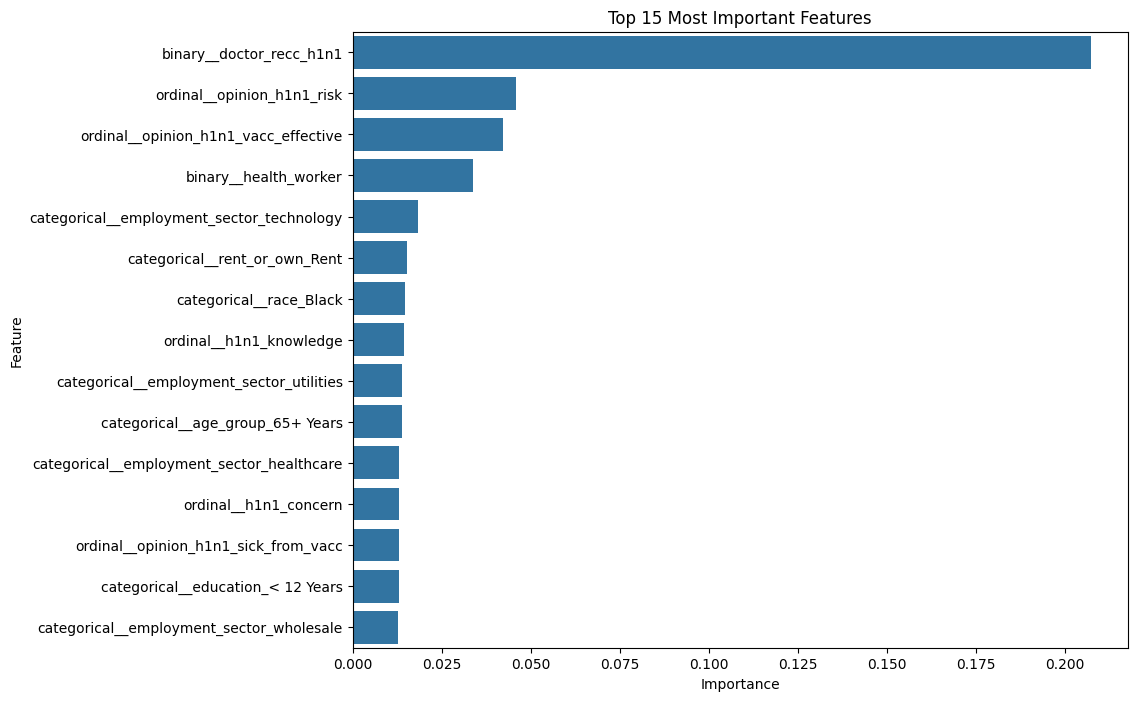

In [37]:

#  FEATURE IMPORTANCE PLOT


top_features = importance_df.head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [38]:
# SHAP EXPLAINER

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values generated successfully")

SHAP values generated successfully


In [39]:
# CLEAN FEATURE NAMES FOR SHAP PLOTS

feature_names = preprocessor.get_feature_names_out()

clean_feature_names = []

for name in feature_names:
    name = name.replace("binary__", "")
    name = name.replace("ordinal__", "")
    name = name.replace("categorical__", "")
    name = name.replace("_", " ")
    clean_feature_names.append(name)

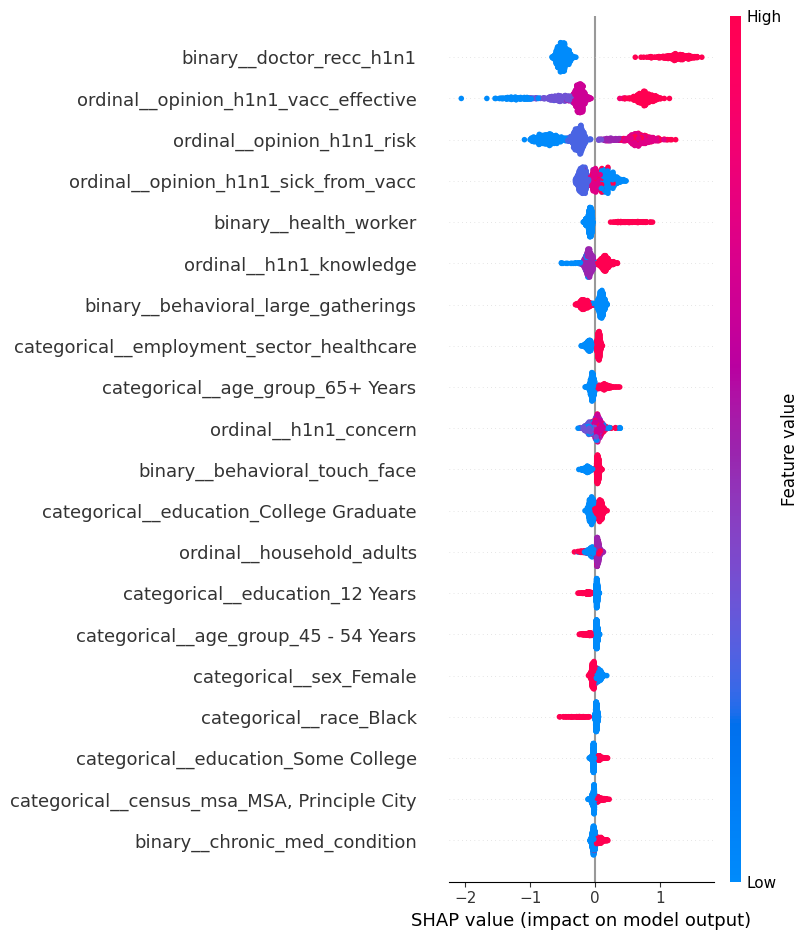

In [45]:

# SHAP SUMMARY PLOT


shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=preprocessor.get_feature_names_out()
)

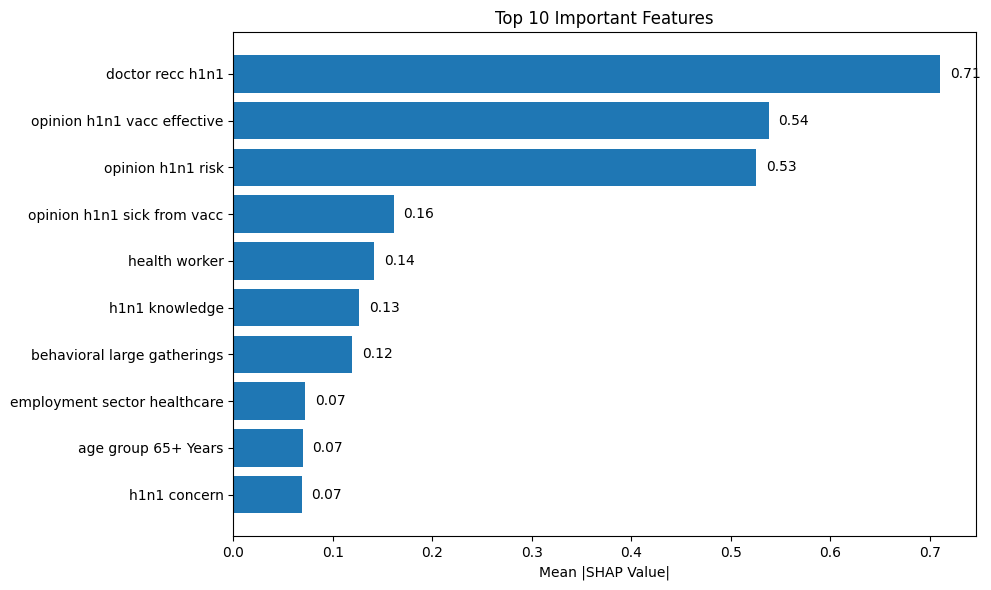

In [43]:
# Mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'SHAP Value': mean_shap
})

# Top 10 features
shap_df = shap_df.sort_values(
    by='SHAP Value',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

ax = plt.barh(
    shap_df['Feature'],
    shap_df['SHAP Value']
)

plt.xlabel("Mean |SHAP Value|")
plt.title("Top 10 Important Features")

# Add values
for i, v in enumerate(shap_df['SHAP Value']):
    plt.text(
        v + 0.01,
        i,
        f"{v:.2f}",
        va='center'
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

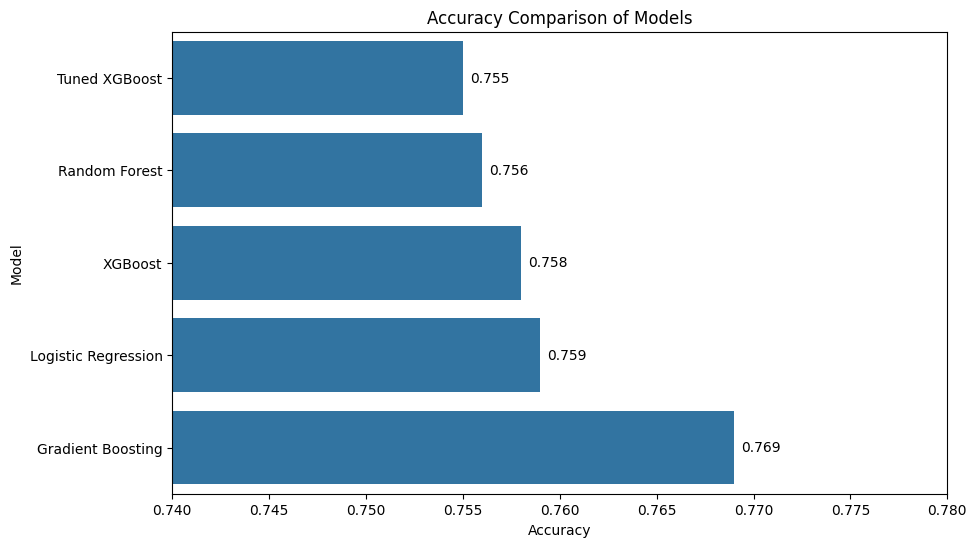

In [ ]:

# ACCURACY COMPARISON


results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Gradient Boosting',
        'Tuned XGBoost'
    ],
    'Accuracy': [
        0.759,
        0.756,
        0.758,
        0.769,
        0.755
    ]
})

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=True
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0.74, 0.78)

plt.show()

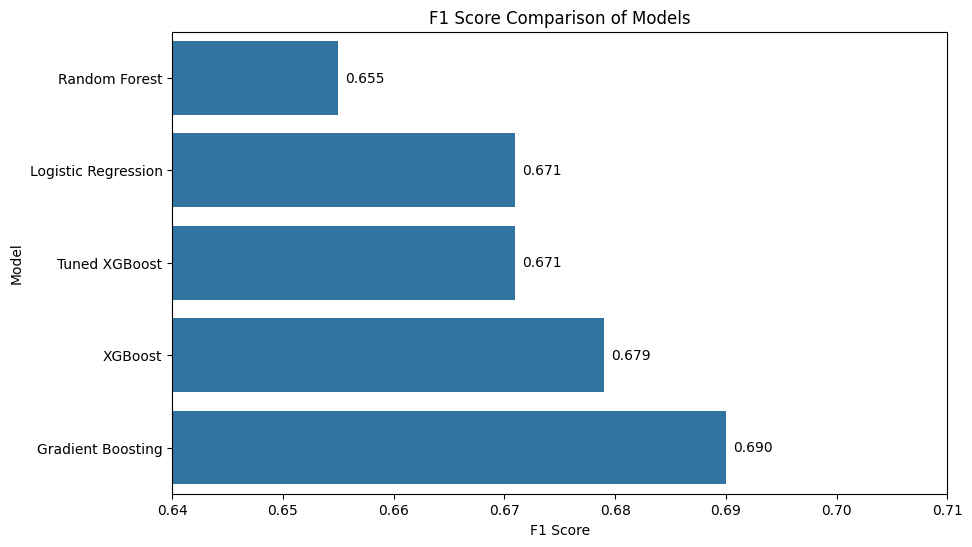

In [ ]:

# F1 SCORE COMPARISON


results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Gradient Boosting',
        'Tuned XGBoost'
    ],
    'F1 Score': [
        0.671,
        0.655,
        0.679,
        0.690,
        0.671
    ]
})

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=True
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results_df,
    x='F1 Score',
    y='Model'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

plt.title("F1 Score Comparison of Models")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0.64, 0.71)

plt.show()

In [ ]:
print("Testing dataset shape:", test_df.shape)
display(test_df.head())

# Check columns
print(test_df.columns)

Testing dataset shape: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,2.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,3.0,4.0,65+ Years,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,65+ Years,College Graduate,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,55 - 64 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,1.0,35 - 44 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition',
       'child_under_6_months', 'health_worker', 'health_insurance',
       'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'age_group', 'education', 'race', 'sex',
       'income_poverty', 'marital_status', 'rent_or_own', 'employment_status',
       'census_msa', 'household_adults', 'household_children',
       'employment_sector'],
      dtype='object')


In [ ]:
from google.colab import files

In [ ]:
files.download("submission_logistic_regression.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("submission_random_forest.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("submission_xgboost.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("submission_tuned_xgboost.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("submission_gradient_boosting.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

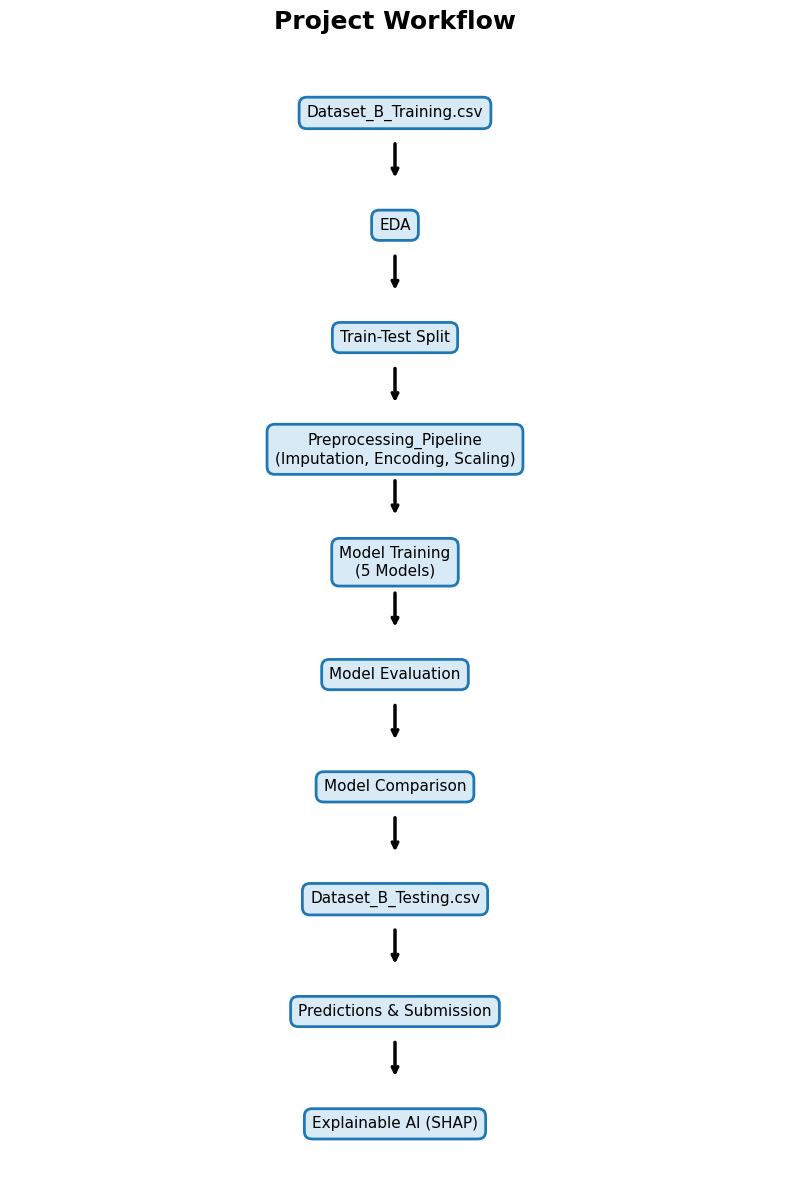

In [ ]:
steps = [
    "Dataset_B_Training.csv",
    "EDA",
    "Train-Test Split",
    "Preprocessing_Pipeline\n(Imputation, Encoding, Scaling)",
    "Model Training\n(5 Models)",
    "Model Evaluation",
    "Model Comparison",
    "Dataset_B_Testing.csv",
    "Predictions & Submission",
    "Explainable AI (SHAP)"
]

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(steps) * 2)
ax.axis('off')

for i, step in enumerate(steps):

    y = len(steps) * 2 - (i * 2 + 1)

    # Box
    ax.text(
        5,
        y,
        step,
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="#D9EAF7",
            ec="#1F77B4",
            lw=2
        )
    )

    # Arrow
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(5, y - 1.2),
            xytext=(5, y - 0.5),
            arrowprops=dict(
                arrowstyle="->",
                lw=2.5
            )
        )

plt.title(
    "Project Workflow",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()